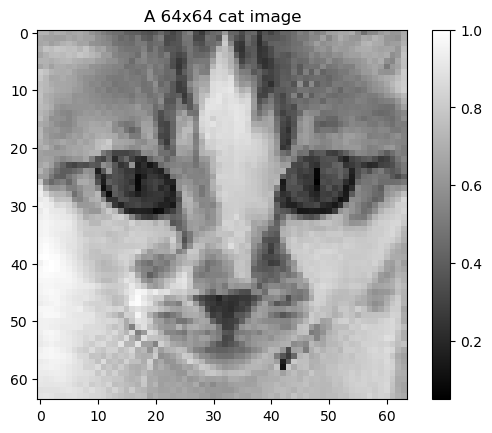

In [42]:
import torch, torchvision
from spyrit.core.meas import HadamSplit2d
from spyrit.core.noise import Poisson
import matplotlib.pyplot as plt
import tensorly as tl
tl.set_backend('pytorch')

# Cat obtained from https://www.kaggle.com/datasets/mahmudulhaqueshawon/cat-image (small)
x = torch.sum(torchvision.io.read_image("../../tensorly_hdr/dataset/cat.jpg"), axis=0)
x = x/torch.max(x)  # normalize to [0,1], this is realistic

plt.imshow(x, cmap='gray')
plt.colorbar()
plt.title("A 64x64 cat image")
plt.show()

We can check that the shape of y, 8192, is 64^2*2=8192, as expected for a split Hadamard of size 64x64


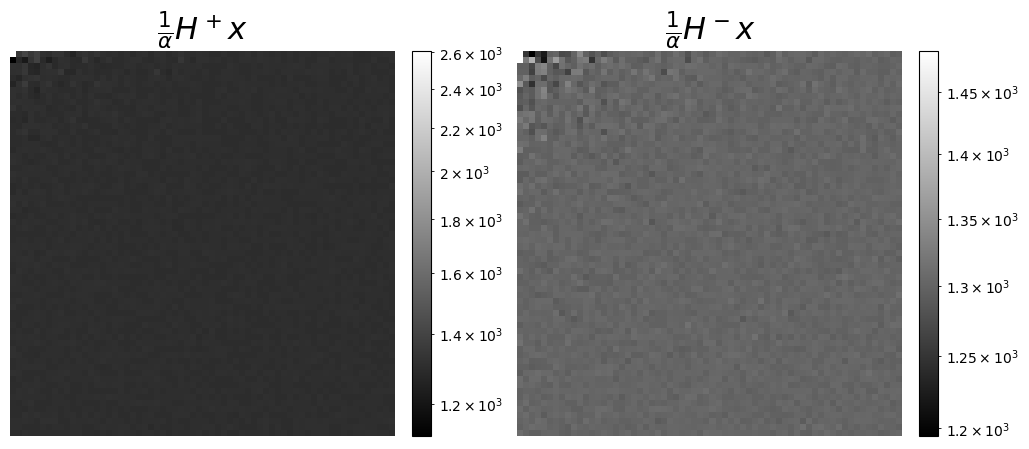

In [43]:
# Simulating the acquisition. We use spyrit's implementation to leverage fast Hadamard transforms
from matplotlib.colors import LogNorm


alpha=1e2
meas_op = HadamSplit2d(64, noise_model=Poisson(alpha))  # this creates the split measurement operator A, and defines the model parameters (noise level)
y = meas_op.forward(x)  # This sampled y~P(\alpha Ax)
y = y/alpha  # rescale to get back the right intensity scale
print(f"We can check that the shape of y, {y.shape[0]}, is 64^2*2=8192, as expected for a split Hadamard of size 64x64")

# We can also visualize the measurements, as coefficients in the Hadamard basis, seen as a wavelet transform. This is more meaningful here to display the coefficients corresponding to the split acuqisitions, H+ and H-

y_pos = y[0::2]
y_neg = y[1::2]  # Note: y[1] is zero

f, axs = plt.subplots(1, 2, figsize=(12, 5))
# Increase title fontsize
axs[0].set_title(r"$\frac{1}{\alpha}H^+x$", fontsize=22)
# In logscale to better see small values
im = axs[0].imshow(y_pos.reshape(64, 64), cmap="gray", norm=LogNorm())
# add a colorbar, that fits the size of the image, and with fixed range
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
axs[1].set_title(r"$\frac{1}{\alpha}H^-x$", fontsize=22)
im = axs[1].imshow(y_neg.reshape(64, 64), cmap="gray", norm=LogNorm())
plt.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
# remove axis for the both plots
axs[0].axis('off')
axs[1].axis('off')
plt.show()

In [44]:
# Reconstruction with pseudo-inverse
# Sadly spyrit does not yet implement fast pseudo-inverse for HadamardSplit2d, so this is slow
x_rec = torch.linalg.lstsq(meas_op.A, y).solution.reshape(64, 64)
print(torch.sum(x_rec[x_rec<0]))
print(torch.sum(x_rec[x_rec>0]))
# Bonus: we can use a nnls solver, also very slow without fast operators
from tensorly.solvers.nnls import hals_nnls
Aty = meas_op.adjoint(y)[:,None]
AtA = meas_op.A.T@meas_op.A
x_rec_nnls = hals_nnls(Aty, AtA, n_iter_max=20, tol=0).reshape(64, 64)


tensor(-0.1275)
tensor(2603.3306)


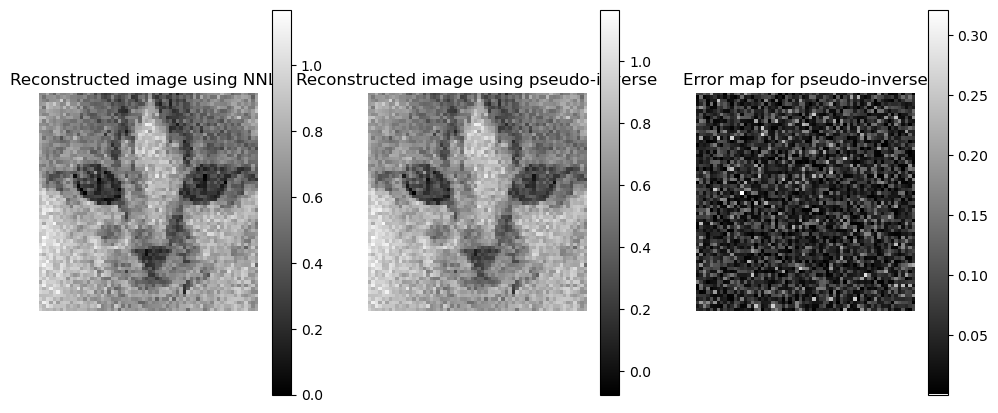

In [45]:

plt.subplots(1, 3, figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(x_rec_nnls, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title("Reconstructed image using NNLS")
plt.subplot(1, 3, 2)
plt.imshow(x_rec, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title("Reconstructed image using pseudo-inverse")
# error map for the pseudo-inverse
plt.subplot(1, 3, 3)
plt.imshow(torch.abs(x - x_rec), cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title("Error map for pseudo-inverse")
plt.show()

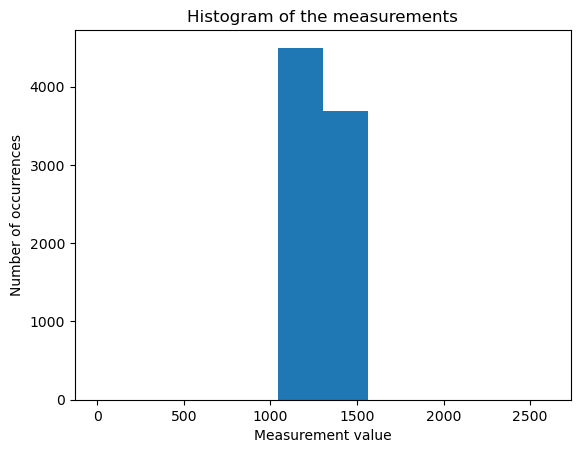

In [46]:
plt.hist(y)
plt.title("Histogram of the measurements")
plt.xlabel("Measurement value")
plt.ylabel("Number of occurrences")
plt.show()

In [47]:
# Reco avec MU
from tensorly_hdr.nmf_kl import Lee_Seung_KL_regression
# remove the second element in y
yr = torch.cat([y[0:1], y[2:]])
Ar = torch.cat([meas_op.A[0:1,:], meas_op.A[2:,:]], dim=0)
crit, x_mu, time, _ = Lee_Seung_KL_regression(yr, Ar, Hini=x_rec_nnls.reshape(64**2), epsilon=1e-8, NbIter=150, tol=1e-6, verbose=True, print_it=50)
#crit, x_mu, time, _ = Lee_Seung_KL_regression(yr, Ar, Hini=torch.rand(64**2), epsilon=1e-8, NbIter=200, tol=1e-6, verbose=True, print_it=10)


------Lee_Sung_KL running------
Loss at initialization: 21.240169525146484
Loss at iteration 1: 21.240060806274414
Loss at iteration 51: 21.23931312561035
Loss at iteration 101: 21.238609313964844
Loss at iteration 150: 21.237985610961914


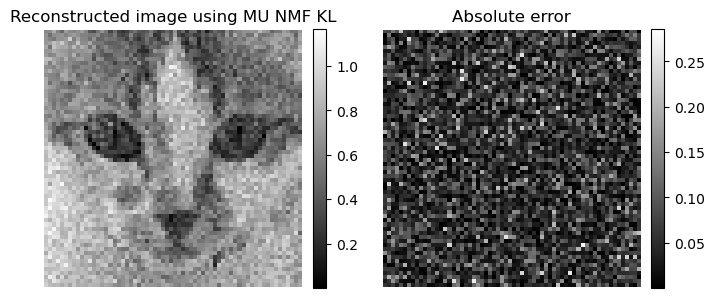

In [48]:
# Show the result
# scale the colorbars
from sympy import fraction


plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.imshow(x_mu.reshape(64,64), cmap='gray')
plt.title("Reconstructed image using MU NMF KL")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1,2,2)
plt.imshow(torch.abs(x - x_mu.reshape(64,64)), cmap='gray')
plt.title("Absolute error")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

In [49]:
# NNLS with subsampling
yr = torch.cat([y[0:1], y[2:]])
Ar = torch.cat([meas_op.A[0:1,:], meas_op.A[2:,:]], dim=0)
# Removing the second half of measurements
yr = yr[:len(Aty)//2]
Ar = Ar[:len(AtA)//2, :]
# Right pseudo-inverse
x_rec_ls_sub = torch.linalg.pinv(Ar)@yr
x_rec_ls_sub = x_rec_ls_sub.reshape(64,64)
# MU initialized with the pseudo-inverse
crit, x_mu_sub, time, _ = Lee_Seung_KL_regression(yr, Ar, Hini=torch.abs(x_rec_ls_sub.reshape(64**2)), epsilon=1e-8, NbIter=100, tol=1e-6, verbose=True, print_it=20)
x_mu_sub = x_mu_sub.reshape(64,64)


------Lee_Sung_KL running------
Loss at initialization: 5.211478233337402
Loss at iteration 1: 5.211469650268555
Loss at iteration 21: 5.211434364318848
Loss at iteration 41: 5.21140193939209
Loss at iteration 61: 5.211381435394287
Loss at iteration 81: 5.211371421813965
Loss at iteration 100: 5.211336135864258


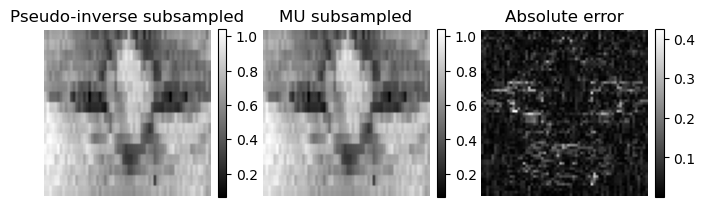

In [50]:
plt.figure(figsize=(8,6))
plt.subplot(1,3,1)
plt.imshow(x_rec_ls_sub, cmap='gray')
plt.title("Pseudo-inverse subsampled")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1,3,2)
plt.imshow(x_mu_sub, cmap='gray')
plt.title("MU subsampled")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1,3,3)
plt.imshow(torch.abs(x - x_mu_sub), cmap='gray')
plt.title("Absolute error")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

tensor(0.0003)
Iteration 0, Cost: 97.61712646484375
Iteration 50, Cost: 95.63774108886719
Iteration 100, Cost: 94.95481872558594
Iteration 150, Cost: 94.57843017578125
Iteration 200, Cost: 94.33049774169922
Iteration 250, Cost: 94.15330505371094


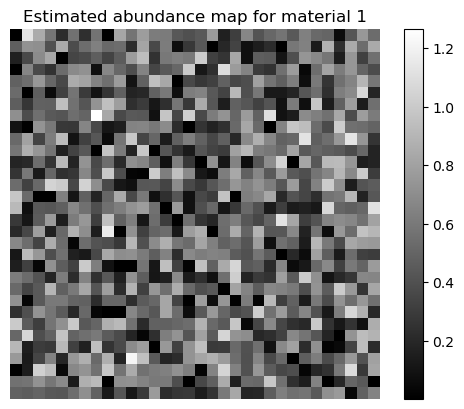

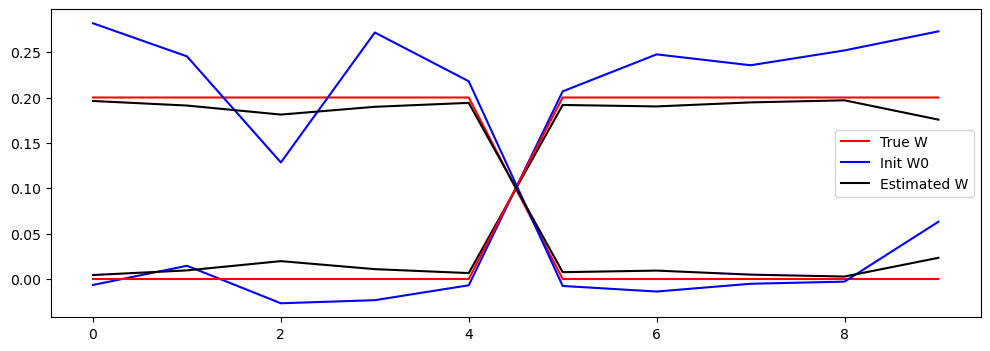

In [ ]:
# Separation on synthetic dataset (Eusipco + HCERES)
import numpy as np
from tensorly_hdr.nmf_kl import MU_SinglePixel
from tensorly_hdr.sep_nmf import spa, snpa

W = torch.tensor([[1,1,1,1,1,0,0,0,0,0],[0,0,0,0,0,1,1,1,1,1]], dtype=torch.float32).T
W = W/torch.sum(W, dim=0, keepdim=True)  # normalize columns
n = 32
At = torch.rand(2, n**2)
At = At/tl.sum(At,axis=0)
At[0,0]=0.99
At[1,1]=0.99
At[0,1]=0.01
At[1,0]=0.01
# Measurement operator is Ar, noiseless
Xtrue = W@At
alpha=1e2
meas_op = HadamSplit2d(n, noise_model=Poisson(alpha))  # this creates the split measurement operator A, and defines the model parameters (noise level)
Ar = torch.cat([meas_op.A[0:1,:], meas_op.A[2:,:]], dim=0) # TODO: adapt to use forward with wavelengths
Y = torch.poisson(alpha*Xtrue@Ar.T)
#Y = meas_op.forward(Xtrue)  # This sampled y~P(\alpha Ax)
Y = Y/alpha  # rescale to get back the right intensity scale

# Init pinv+snpa
X_rec = torch.linalg.lstsq(Ar, Y.T).solution.T

print(tl.norm(X_rec-Xtrue,'fro')/np.prod(tl.shape(Xtrue)))

Kset, W0, A0 = snpa(X_rec, 2)

# Reconstruction with NMF
W_est, A_est, crit = MU_SinglePixel(Y, Ar, tl.abs(A0), tl.abs(W0), lmbd=1e-3, maxA=None, niter=300, n_iter_inner=20, eps=1e-8, verbose=True, print_it=50)
# Normalization of W_est and A_est
sum_W_est = torch.sum(W_est, dim=0, keepdim=True)
W_est = W_est/sum_W_est
A_est = A_est*sum_W_est.T
# Show one of the estimated abundance maps
plt.imshow(A_est[0,:].reshape(n,n), cmap='gray')
plt.title("Estimated abundance map for material 1")
plt.colorbar()
plt.axis('off')
plt.show()

# Plot true W and esimated W and init W0
# adapt these lines to have 2 line plots for each matrix with the same color
plt.figure(figsize=(12,4))
plt.plot(W[:,0].cpu().numpy(), 'r')
plt.plot(W0[:,0].cpu().numpy(), 'b')
plt.plot(W_est[:,0].cpu().numpy(), 'k')
plt.legend(['True W', 'Init W0', 'Estimated W'])
plt.plot(W[:,1].cpu().numpy(), 'r')
plt.plot(W0[:,1].cpu().numpy(), 'b')
plt.plot(W_est[:,1].cpu().numpy(), 'k')
plt.legend(['True W', 'Init W0', 'Estimated W'])
plt.show()

tensor(0.0003)
Iteration 0, Cost: 96.40030670166016
Iteration 50, Cost: 95.7707748413086
Iteration 100, Cost: 95.40318298339844
Iteration 150, Cost: 95.141845703125
Iteration 200, Cost: 94.94414520263672
Iteration 250, Cost: 94.78937530517578


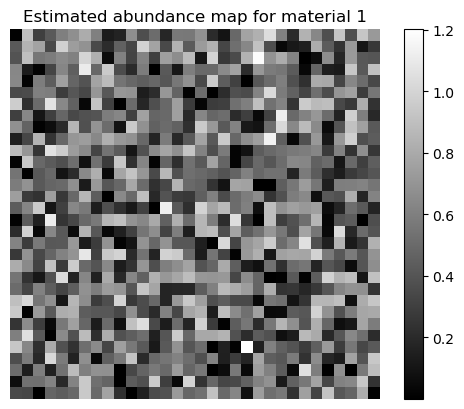

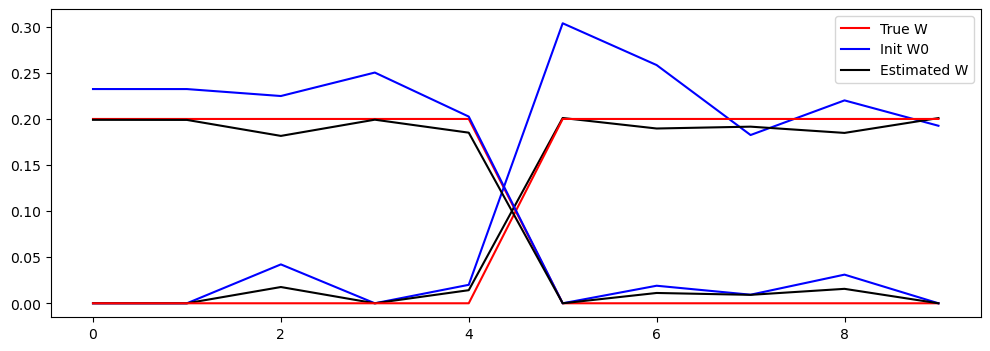

In [52]:
# Separation on synthetic dataset (Eusipco + HCERES)
import numpy as np
from tensorly_hdr.nmf_kl import MU_SinglePixel
from tensorly_hdr.sep_nmf import snpa, spa
from tensorly_hdr.nmf_kl import Lee_Seung_KL_regression
from tensorly.solvers import hals_nnls

W = torch.tensor([[1,1,1,1,1,0,0,0,0,0],[0,0,0,0,0,1,1,1,1,1]], dtype=torch.float32).T
W = W/torch.sum(W, dim=0, keepdim=True)  # normalize columns
n = 32
At = torch.rand(2, n**2)
At = At/tl.sum(At,axis=0)
At[0,0]=0.99
At[1,1]=0.99
At[0,1]=0.01
At[1,0]=0.01
# Measurement operator is Ar, noiseless
Xtrue = W@At
alpha=1e2
meas_op = HadamSplit2d(n, noise_model=Poisson(alpha))  # this creates the split measurement operator A, and defines the model parameters (noise level)
Ar = torch.cat([meas_op.A[0:1,:], meas_op.A[2:,:]], dim=0) # TODO: adapt to use forward with wavelengths
Y = torch.poisson(alpha*Xtrue@Ar.T)
#Y = meas_op.forward(Xtrue)  # This sampled y~P(\alpha Ax)
Y = Y/alpha  # rescale to get back the right intensity scale

# Init pinv+spa
#X_rec = torch.linalg.lstsq(Ar, Y.T).solution.T
# Init NNLS + snpa
X_rec = hals_nnls(Ar.T@Y.T, Ar.T@Ar, n_iter_max=10).T

print(tl.norm(X_rec-Xtrue,'fro')/np.prod(tl.shape(Xtrue)))

Kset, W0, A0 = snpa(X_rec, 2)

# Reconstruction with NMF (TODO bugged ? moves from optimal when oracle init)
W_est, A_est, crit = MU_SinglePixel(Y, Ar, tl.abs(A0), tl.abs(W0), lmbd=0, maxA=None, niter=300, n_iter_inner=20, eps=1e-8, verbose=True, print_it=50)
# Normalization of W_est and A_est
sum_W_est = torch.sum(W_est, dim=0, keepdim=True)
W_est = W_est/sum_W_est
A_est = A_est*sum_W_est.T
# Show one of the estimated abundance maps
plt.imshow(A_est[0,:].reshape(n,n), cmap='gray')
plt.title("Estimated abundance map for material 1")
plt.colorbar()
plt.axis('off')
plt.show()

# Plot true W and esimated W and init W0
# adapt these lines to have 2 line plots for each matrix with the same color
plt.figure(figsize=(12,4))
plt.plot(W[:,0].cpu().numpy(), 'r')
plt.plot(W0[:,0].cpu().numpy(), 'b')
plt.plot(W_est[:,0].cpu().numpy(), 'k')
plt.legend(['True W', 'Init W0', 'Estimated W'])
plt.plot(W[:,1].cpu().numpy(), 'r')
plt.plot(W0[:,1].cpu().numpy(), 'b')
plt.plot(W_est[:,1].cpu().numpy(), 'k')
plt.legend(['True W', 'Init W0', 'Estimated W'])
plt.show()

# Try deaing with real data

Shape of measurements tensor (wavelengths x measurements):  (8192, 2048)


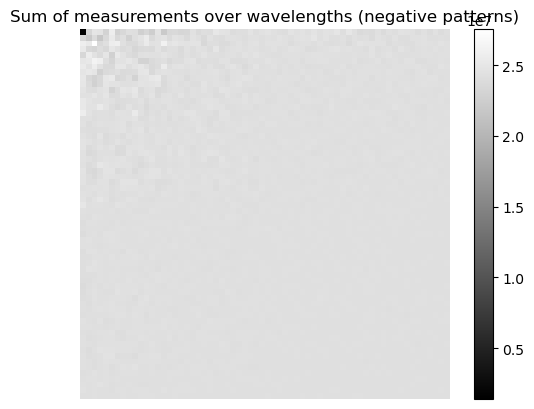

In [53]:
# Loading
import numpy as np
import json
import ast

data = np.load("../../tensorly_hdr/dataset/obj_Cat_bicolor_thin_overlap_source_white_LED_Walsh_im_64x64_ti_9ms_zoom_x1_spectraldata.npz", allow_pickle=True)

Ymeas = data["spectral_data"] # the only valid key --> why

# Metadata --> not a correct naming, contains in particular the pattern indices !!!
file = open("../../tensorly_hdr/dataset/obj_Cat_bicolor_thin_overlap_source_white_LED_Walsh_im_64x64_ti_9ms_zoom_x1_metadata.json", "r")
json_metadata = json.load(file)[4]
file.close()

# replace "np.int32(" with an empty string and ")" with an empty string
tmp = json_metadata["patterns"]
tmp = tmp.replace("np.int32(", "").replace(")", "")
patterns = ast.literal_eval(tmp)  # the list (of list of) of pattern indices (evaluation because stored as text...)
wavelengths = ast.literal_eval(json_metadata["wavelengths"])


# Permutation of measurements
from spyrit.misc import sampling as samp
subsampling_factor = 1
img_size = 64

acq_size = img_size // subsampling_factor
Ord_acq = (-np.array(patterns)[::2] // 2).reshape((acq_size, acq_size))

# Measurement and noise operators
Ord_rec = torch.ones(img_size, img_size)

# %%
# Define the two permutation matrices used to reorder the measurements
# measurement order -> natural order -> reconstruction order
Perm_rec = samp.Permutation_Matrix(Ord_rec)
Perm_acq = samp.Permutation_Matrix(Ord_acq).T
# each element of 'measurements' has shape (measurements, wavelengths)
Ymeas = samp.reorder(Ymeas, Perm_acq, Perm_rec)

print("Shape of measurements tensor (wavelengths x measurements): ", Ymeas.shape)
# Plotting the measurements summed over wavelengths
Ymeas_sum_pos = np.sum(Ymeas[::2,:], axis=1)
Ymeas_sum_neg = np.sum(Ymeas[1::2,:], axis=1)
plt.imshow(Ymeas_sum_neg.reshape((acq_size, acq_size)), cmap='gray')
plt.title("Sum of measurements over wavelengths (negative patterns)")
plt.colorbar()
plt.axis('off')
plt.show()

Estimated dark current to remove: 688.939453125


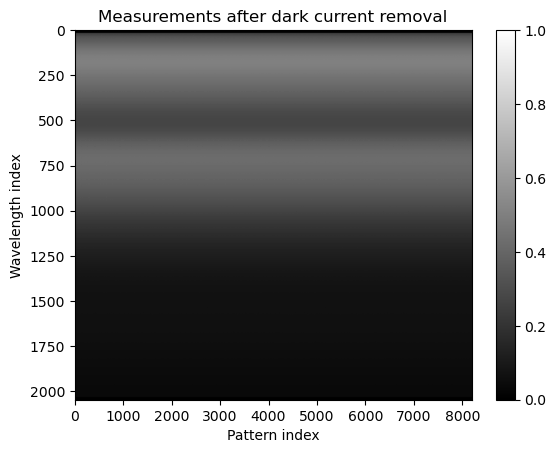

In [54]:
# Post-processing of the measurements
# Make a wavelength x measurements tensor
Y = torch.tensor(Ymeas, dtype=torch.float32).T
#del Ymeas#, Ymeas_perm  # free memory

# Unbiais by removing the dark current, estimated as the min value of marginals of Y (better?)
#dc = tl.min(tl.sum(Y, axis=0))/Y.shape[0]
dc = tl.sum(Y[:,1])/Y.shape[0] # average of dc over all wavelengths
print(f"Estimated dark current to remove: {dc}")
Y = Y - dc
#print(Y[:5,:5])  # show a small part of Y
# clip negative values
Y = tl.clip(Y, 0, tl.max(Y))
# Normalization to [0,1]
Y = Y / tl.max(Y)

# Showing the measurements after dark current removal
plt.imshow(Y.cpu().numpy(), aspect='auto', cmap='gray')
plt.title("Measurements after dark current removal")
plt.xlabel("Pattern index")
plt.ylabel("Wavelength index")
plt.colorbar()
plt.show()

In [61]:
# Reconstruction with pseudo-inverse
from spyrit.core.meas import HadamSplit2d
import spyrit.misc.sampling as samp

n=64

# PAtterns are acquired in order Acq, compared to order nat
# Patterns are stored in order Rec in spyrit
acq_size = n
meas_op = HadamSplit2d(n)
A = meas_op.A  # noiseless operator
Anz = torch.cat([A[0:1,:], A[2:,:]], dim=0)
print(Anz.shape)

# Remove row of zero
# Remove 16 first bands that are null
nbremove = 16
Ynz = torch.cat([Y[nbremove:,0:1], Y[nbremove:,2:]], dim=1)
wavelengths_nz = wavelengths[nbremove:]
print(f"Measurements shape after removing zero rows and first 16 bands: {Ynz.shape}")
# five bands binning
bin_size = 8
Ynz_binned = tl.zeros((Ynz.shape[0]//bin_size, Ynz.shape[1]))
wavelengths_binned = []
for i in range(0, Ynz.shape[0], bin_size):
    if i+bin_size <= Ynz.shape[0]:
        Ynz_binned[i//bin_size,:] = tl.mean(Ynz[i:i+bin_size,:], axis=0)
        wavelengths_binned.append(np.mean(wavelengths_nz[i:i+bin_size]))
    else:
        Ynz_binned[i//bin_size,:] = tl.mean(Ynz[i:,:], axis=0)
        wavelengths_binned.append(np.mean(wavelengths_nz[i:]))
Ynz = Ynz_binned
wavelengths_nz = wavelengths_binned
print(f"Binned measurements shape: {Ynz.shape}")

# useful for algorithm
#sumH = torch.ones((Ynz.shape[0], 2*n**2-1))@Anz  # (H.T @ 1).T
#print(sumH.shape)

# define custom foward and adjoint forward functions
def forward(x):
    # x@Anz.T or Anz@x
    # x is of shape (B, N**2)  # batch first
    # reshape to (B, N, N)
    temp = x.reshape((x.shape[0], n, n))  # Whyyyyyyy >????
    temp = meas_op.forward(temp).T  # shape (M, B)
    # Removing the zero row of A changes the forward A@X
    return torch.cat([temp[0:1,:], temp[2:,:]], dim=0)
def adjoint(y):
    # y is of shape (B, M)
    # need to add a zero column in y, after the first column
    temp = torch.cat([y[:, 0:1], torch.zeros((y.shape[0], 1)), y[:, 1:]], dim=1)  # add zero column
    temp = meas_op.adjoint(temp)  # shape (B, M)
    return temp
def adjoint_faster(y):
    # sad :(
    return y@Anz
#sumH = torch.ones()

# Pseudo-inverse reconstruction
X_rec = torch.linalg.lstsq(Anz, Ynz.T).solution.T
#X_rec = hals_nnls(Anz.T@Ynz.T, Anz.T@Anz, n_iter_max=10, epsilon=1e-8).T  # too slow

print(Ynz.shape)  # should be (num_wavelengths, n^2)
print(X_rec.shape)  # should be (num_wavelengths, n^2)


torch.Size([8191, 4096])
Measurements shape after removing zero rows and first 16 bands: torch.Size([2032, 8191])
Binned measurements shape: torch.Size([254, 8191])
torch.Size([254, 8191])
torch.Size([254, 4096])


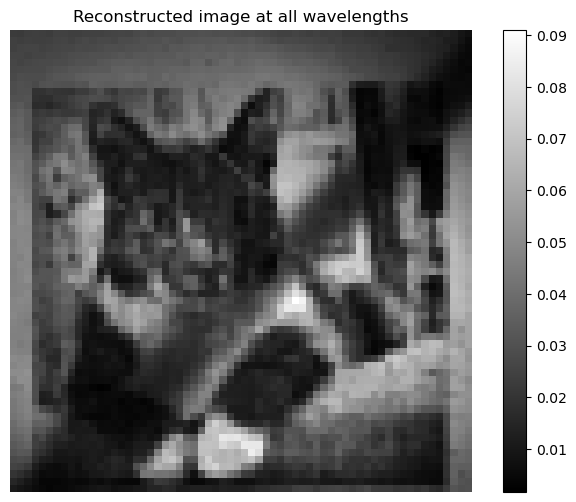

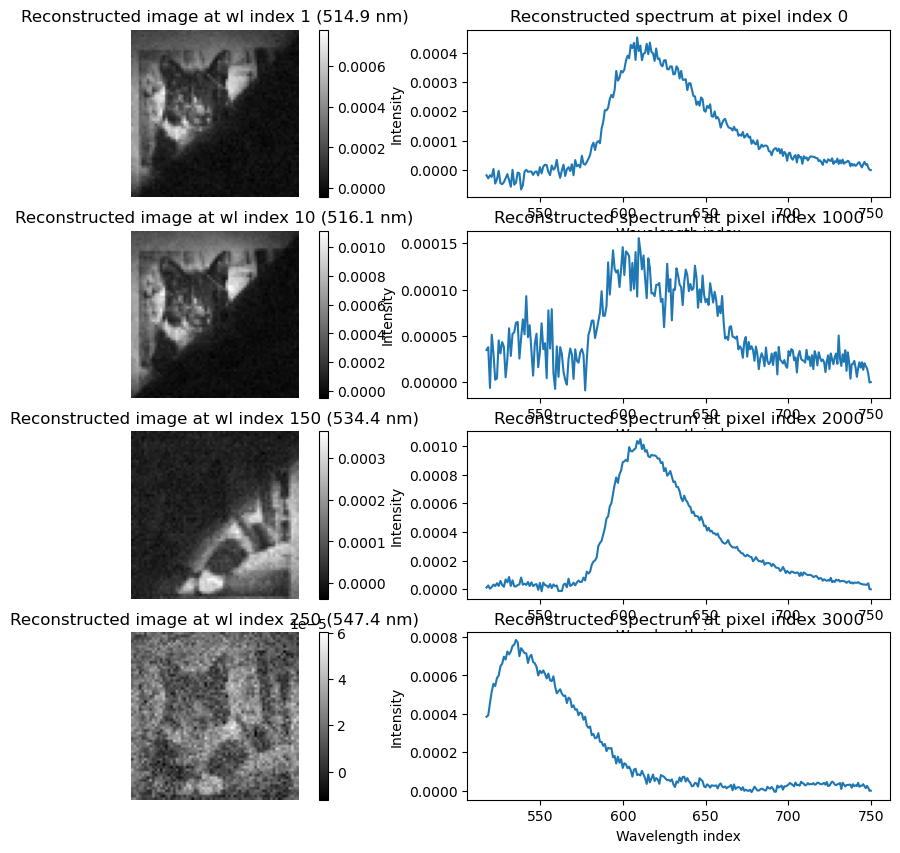

In [ ]:
# Show cat reconstructed with all wavelengths
plt.figure(figsize=(8,6))
plt.imshow(np.rot90(torch.sum(X_rec, dim=0).reshape(64,64), 2), cmap='gray')
plt.title("Reconstructed image at all wavelengths")
plt.colorbar()
plt.axis('off')



In [ ]:
# Running the NMF-based unmixing on the reconstructed hypercube
# Init pinv+spa
rank = 3
#Kset, W0, A0 = spa(X_rec, rank)
Kset, W0, A0 = snpa(X_rec, rank, verbose=True)

# Reconstruction with NMF
from tensorly_hdr.nmf_kl import MU_SinglePixel_fast
lmbd = 1e-3#[1e-4, 0]
#W_est, A_est, crit = MU_SinglePixel(Ynz, Anz, tl.abs(A0), tl.abs(W0), lmbd=lmbd, maxA=1, niter=10, n_iter_inner=20, eps=1e-8, verbose=True, print_it=1)  # regularization just for implicit scaling
W_est, A_est, crit = MU_SinglePixel_fast(Ynz, forward, adjoint_faster, tl.abs(A0), tl.abs(W0), lmbd=lmbd, maxA=1, niter=100, n_iter_inner=20, eps=1e-8, verbose=True, print_it=20)  # regularization just for implicit scaling
# Normalization of W_est and A_est
#sum_W_est = torch.sum(W_est, dim=0, keepdim=True)
#W_est = W_est/sum_W_est
#A_est = A_est*sum_W_est.T
print("Computation done")

0 [0, 0, 0]
1 [1688, 0, 0]
2 [1688, 2547, 0]
Returning [1688, 2547, 1816] as estimated pure pixel indices
Iteration 0, Cost: 4.545459270477295
Iteration 20, Cost: 4.496109962463379
Iteration 40, Cost: 4.458509922027588
Iteration 60, Cost: 4.428737640380859
Iteration 80, Cost: 4.404552459716797
Computation done


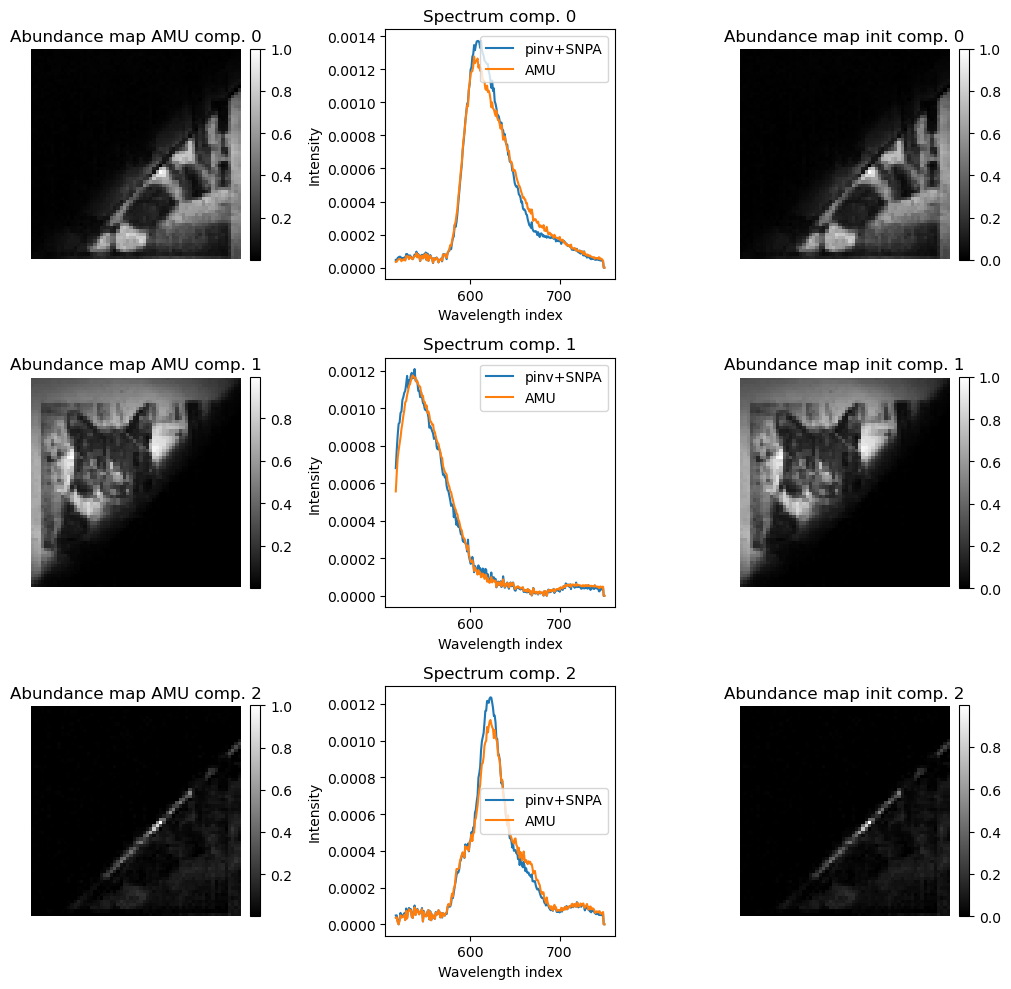

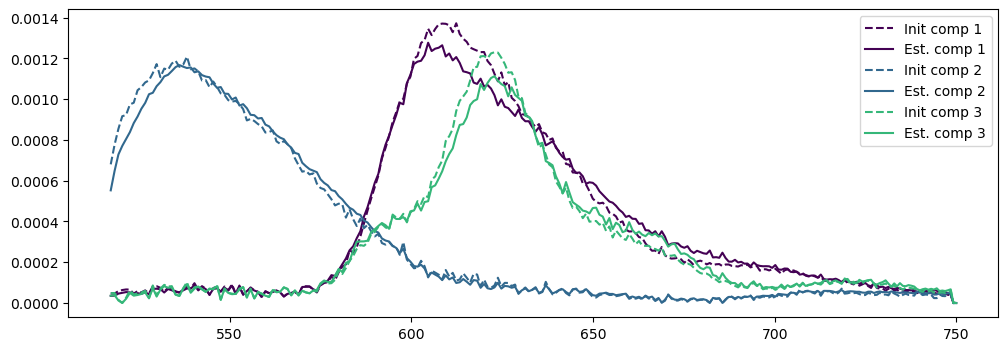

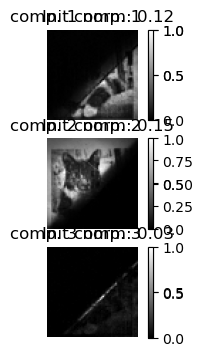

In [ ]:
# show hypercube at some wavelengths and some spectra
plt.figure(figsize=(10,10))
for i in range(rank):
    plt.subplot(rank,3,3*i+1)
    plt.imshow(np.rot90(A_est[i,:].reshape(64,64), 2), cmap='gray')
    plt.title(f"Abundance map AMU comp. {i+1}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.subplot(rank,3,3*i+2)
    plt.plot(wavelengths_nz, W0[:,i].cpu().numpy())
    plt.plot(wavelengths_nz, W_est[:,i].cpu().numpy())
    plt.title(f"Spectrum comp. {i+1}")
    plt.xlabel("Wavelength index")
    plt.ylabel("Intensity") 
    plt.legend(["pinv+SNPA", "AMU"])
    plt.subplot(rank,3,3*i+3)
    plt.imshow(np.rot90(A0[i,:].reshape(64,64), 2), cmap='gray')
    plt.title(f"Abundance map init comp. {i+1}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.tight_layout()
plt.show()


# PLot the initial and estimated spectra
norms = [torch.linalg.norm(W_est[:,i])*torch.linalg.norm(A_est[i,:]) for i in range(rank)]
Anorms = [torch.max(A_est[i,:]) for i in range(rank)]
A0norms = [torch.max(A0[i,:]) for i in range(rank)]
plt.figure(figsize=(12,4))
legend = []
for i in range(rank):
    # use a different color for each component
    colors = plt.cm.viridis(i / rank)
    plt.plot(wavelengths_nz, A0norms[i]*W0[:,i].cpu().numpy(), '--', color=colors)
    plt.plot(wavelengths_nz, Anorms[i]*W_est[:,i].cpu().numpy(), color=colors)
    #plt.legend(['Init W0', 'Estimated W'])
    legend.append(f"Init comp {i+1}")
    legend.append(f"Est. comp {i+1}")
plt.legend(legend)
plt.show()

# norm of components
# and their abundance maps, both init and NMF
plt.figure(figsize=(12,4))
for i in range(rank):
    plt.subplot(rank,3,3*i+1)
    plt.imshow(np.rot90(A_est[i,:].reshape(n,n), 2), cmap='gray')
    plt.title(f"comp. {i+1} norm: {norms[i]:.2f}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.subplot(rank,3,3*i+1)  
    plt.imshow(np.rot90(A0[i,:].reshape(n,n), 2), cmap='gray')
    plt.title(f"Init comp. {i+1}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
plt.show()

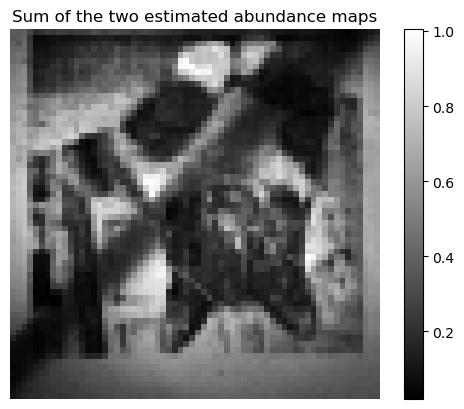

In [65]:
# Plot the sum of the two maps, to see if they cover the whole image
plt.imshow(torch.sum(A_est, axis=0).reshape(n,n), cmap='gray')
plt.title("Sum of the two estimated abundance maps")
plt.colorbar()
plt.axis('off')
plt.show()

# Show residual map (pseudo-inverse reconstruction used as GT)
#residual = torch.abs(X_rec - W_est@A_est)
#plt.figure(figsize=(6,6))
#plt.imshow(residual.cpu().numpy(), aspect='auto', cmap='gray')
#plt.title("Residual map after NMF unmixing")
#plt.colorbar()
#plt.axis('off')
#plt.show()

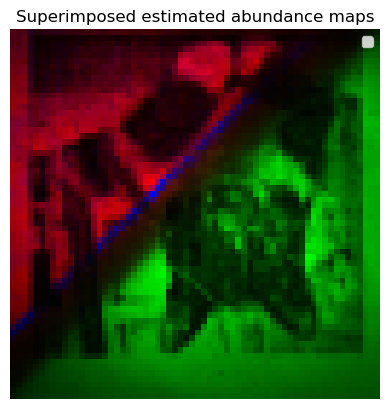

In [67]:
# Superimpose the four estimated abundance maps in an RBG image with four different colors
abundance_map_rgb = torch.zeros((n, n, 3))
# First component in red
abundance_map_rgb[:,:,0] += A_est[0,:].reshape(n,n)
# Second component in green
abundance_map_rgb[:,:,1] += A_est[1,:].reshape(n,n)
# Third component in blue
abundance_map_rgb[:,:,2] += A_est[2,:].reshape(n,n)
if rank>3:
    # Fourth component in yellow (red+green)
    abundance_map_rgb[:,:,0] += A_est[3,:].reshape(n,n)
    abundance_map_rgb[:,:,1] += A_est[3,:].reshape(n,n)
    if rank > 4:
        # use magenta for the fifth component (red+blue)
        abundance_map_rgb[:,:,0] += A_est[4,:].reshape(n,n)
        abundance_map_rgb[:,:,2] += A_est[4,:].reshape(n,n)
        if rank > 5:
            # use cyan for the sixth component (green+blue)
            abundance_map_rgb[:,:,1] += A_est[5,:].reshape(n,n)
            abundance_map_rgb[:,:,2] += A_est[5,:].reshape(n,n)
# Clip values to [0,1]
abundance_map_rgb = torch.clamp(abundance_map_rgb, 0, 1)
plt.imshow(abundance_map_rgb.cpu().numpy())
plt.title("Superimposed estimated abundance maps")
plt.axis('off')
# add color legends
plt.legend(['Component 1 (Red)', 'Component 2 (Green)', 'Component 3 (Blue)', 'Component 4 (Yellow)', 'Component 5 (Magenta)', 'Component 6 (Cyan)'][:rank], loc='upper right')
plt.show()